In [7]:
# 필요한 라이브러리 불러오기
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler   # 추가
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. 데이터 로드
data = pd.read_csv('../datasets/heart.csv')

# 2. 입력(X)과 출력(y) 분리
X = data.drop('output', axis=1)
y = data['output']

# 3. 데이터를 학습용과 테스트용으로 나누기
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 4. 데이터 스케일링
scaler = StandardScaler()

# 학습 데이터로 scaler 학습 후 변환
X_train_scaled = scaler.fit_transform(X_train)

# 테스트 데이터는 transform만 수행
X_test_scaled = scaler.transform(X_test)

# 5. 모델 생성 및 학습
model = LogisticRegression(max_iter=1000)

# 스케일링된 데이터로 학습
model.fit(X_train_scaled, y_train)

# 6. 테스트 데이터로 예측 수행
y_pred = model.predict(X_test_scaled)

# 7. 모델 평가
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# 결과 출력
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)

Accuracy: 0.8524590163934426
Confusion Matrix:
 [[25  4]
 [ 5 27]]


Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



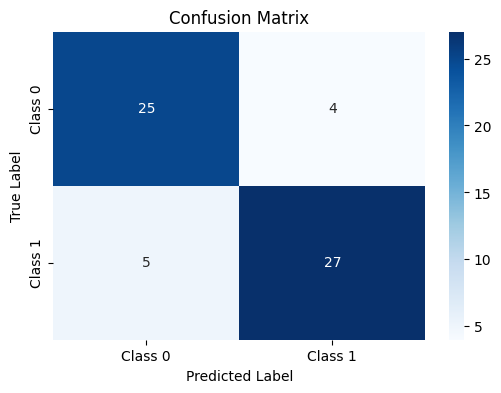

In [ ]:
from sklearn.metrics import classification_report

# 정밀도, 재현율, F1 스코어 출력 
print("Classification Report:\n", classification_report(y_test, y_pred))

import seaborn as sns 
import matplotlib.pyplot as plt

# 혼동 행렬 시각화 
plt.figure(figsize=(6, 4)) 
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Class 0", "Class 1"], 
            yticklabels=["Class 0", "Class 1"]) 
plt.title("Confusion Matrix") 
plt.xlabel("Predicted Label") 
plt.ylabel("True Label") 
plt.show()